In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00404_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00418_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00428_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00158_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00439_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00437_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00166_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_segm/UPENN-GBM-00418_11_segm.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_segm/UPENN-GBM-00158_11_segm.nii
/kag

In [3]:
import pandas as pd

clinical = pd.read_csv("/kaggle/input/datasets/neel17madhavpadhi/gbm-csv/UPENN-GBM_clinical_info_v2.1 (1).csv")

print("Columns:\n", clinical.columns)
print("\nFirst 5 rows:")
clinical.head()

Columns:
 Index(['ID', 'Gender', 'Age_at_scan_years',
       'Survival_from_surgery_days_UPDATED', 'Survival_Status',
       'Survival_Censor', 'IDH1', 'MGMT', 'KPS', 'GTR_over90percent',
       'Time_since_baseline_preop', 'PsP_TP_score'],
      dtype='object')

First 5 rows:


,ID,Gender,Age_at_scan_years,Survival_from_surgery_days_UPDATED,Survival_Status,Survival_Censor,IDH1,MGMT,KPS,GTR_over90percent,Time_since_baseline_preop,PsP_TP_score
0,UPENN-GBM-00001_11,F,52.16,960,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
1,UPENN-GBM-00002_11,F,61.30,291,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
2,UPENN-GBM-00003_11,M,42.82,2838,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN
3,UPENN-GBM-00004_11,M,33.43,623,Deceased,Not Available,NOS/NEC,Not Available,Not Available,Y,0,NaN
4,UPENN-GBM-00005_11,M,53.33,1143,Deceased,Not Available,Wildtype,Not Available,Not Available,Y,0,NaN


In [4]:
import os

structural_path = "/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural"

files = os.listdir(structural_path)

patient_ids = [f.replace("_T1GD.nii.gz", "") for f in files]

print("Patients in imaging dataset:")
print(patient_ids)

Patients in imaging dataset:
['UPENN-GBM-00404_11_T1GD.nii', 'UPENN-GBM-00418_11_T1GD.nii', 'UPENN-GBM-00428_11_T1GD.nii', 'UPENN-GBM-00158_11_T1GD.nii', 'UPENN-GBM-00439_11_T1GD.nii', 'UPENN-GBM-00437_11_T1GD.nii', 'UPENN-GBM-00166_11_T1GD.nii']


In [5]:
clinical["ID"].head()

0    UPENN-GBM-00001_11
1    UPENN-GBM-00002_11
2    UPENN-GBM-00003_11
3    UPENN-GBM-00004_11
4    UPENN-GBM-00005_11
Name: ID, dtype: object

In [6]:
patient_ids_clean = [p.replace("_11", "") for p in patient_ids]

In [7]:
patient_ids_clean = [p.replace("_11", "") for p in patient_ids]

In [8]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [9]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

base = "/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10"

patient = "UPENN-GBM-00404_11"

t1gd_path = f"{base}/images_structural/{patient}_T1GD.nii"
seg_path = f"{base}/images_segm/{patient}_segm.nii"
rcbv_path = f"{base}/images_DSC/{patient}_DSC_ap-rCBV.nii"

print(t1gd_path)
print(seg_path)
print(rcbv_path)

t1gd = nib.load(t1gd_path).get_fdata()
seg = nib.load(seg_path).get_fdata()
rcbv = nib.load(rcbv_path).get_fdata()

print("Shapes:")
print(t1gd.shape, seg.shape, rcbv.shape)

/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00404_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_segm/UPENN-GBM-00404_11_segm.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_DSC/UPENN-GBM-00404_11_DSC_ap-rCBV.nii
Shapes:
(240, 240, 155) (240, 240, 155) (240, 240, 155)


In [10]:
t1gd_img = nib.load("/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural/UPENN-GBM-00404_11_T1GD.nii")
seg_img = nib.load("/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_segm/UPENN-GBM-00404_11_segm.nii")
rcbv_img = nib.load("/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_DSC/UPENN-GBM-00404_11_DSC_ap-rCBV.nii")

print("T1GD spacing:", t1gd_img.header.get_zooms())
print("Seg spacing:", seg_img.header.get_zooms())
print("rCBV spacing:", rcbv_img.header.get_zooms())

T1GD spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Seg spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
rCBV spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


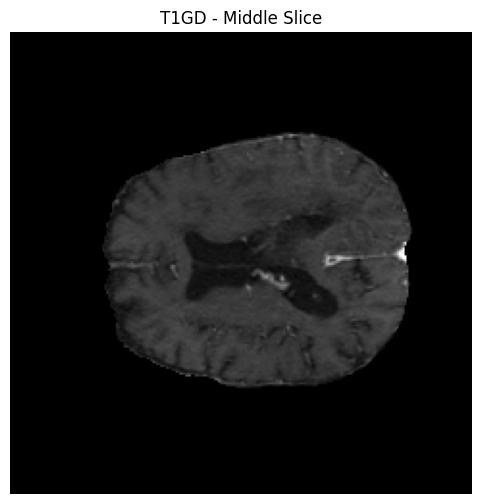

In [11]:
# Select middle slice
slice_idx = t1gd.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(t1gd[:, :, slice_idx], cmap='gray')
plt.title("T1GD - Middle Slice")
plt.axis('off')
plt.show()

In [12]:
tumor_volume_per_slice = np.sum(seg > 0, axis=(0,1))
slice_idx = np.argmax(tumor_volume_per_slice)

print("Best tumor slice:", slice_idx)

Best tumor slice: 93


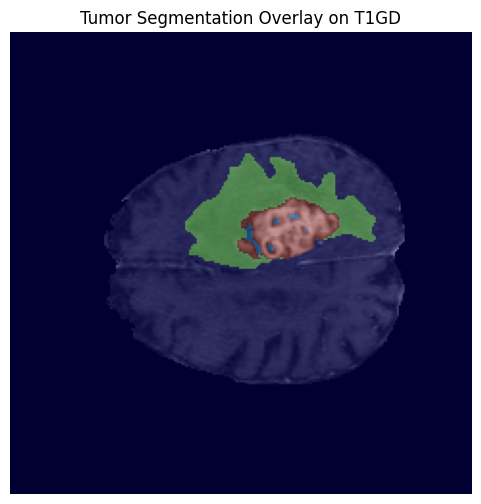

In [13]:
plt.figure(figsize=(6,6))
plt.imshow(t1gd[:, :, slice_idx], cmap='gray')
plt.imshow(seg[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Tumor Segmentation Overlay on T1GD")
plt.axis('off')
plt.show()

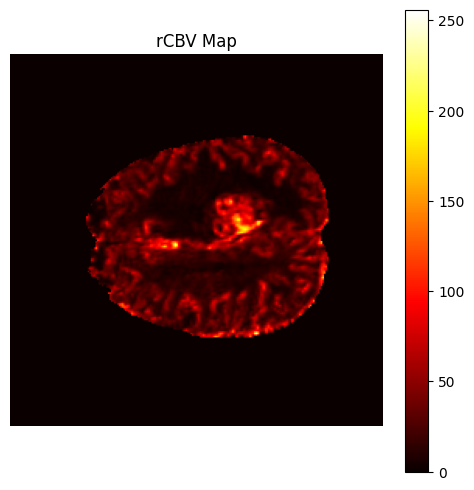

In [14]:
plt.figure(figsize=(6,6))
plt.imshow(rcbv[:, :, slice_idx], cmap='hot')
plt.title("rCBV Map")
plt.axis('off')
plt.colorbar()
plt.show()

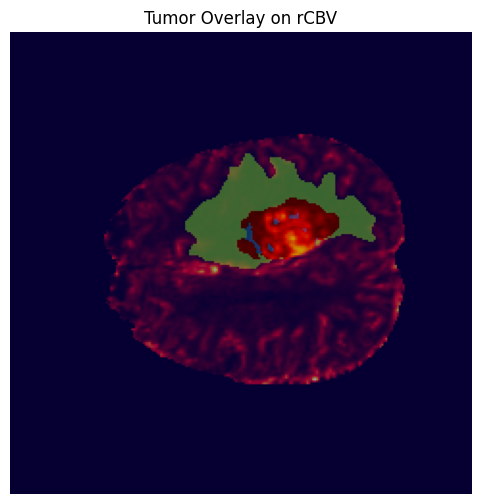

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(rcbv[:, :, slice_idx], cmap='hot')
plt.imshow(seg[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Tumor Overlay on rCBV")
plt.axis('off')
plt.show()

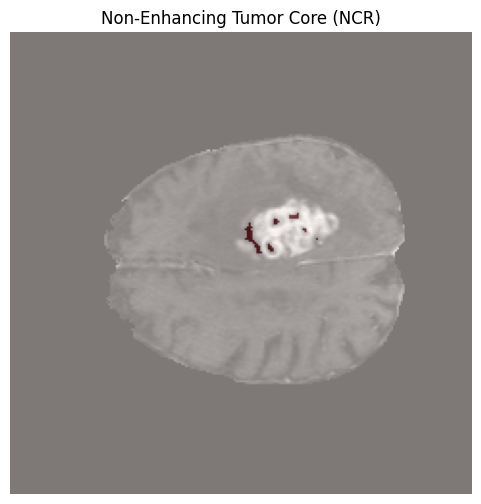

In [16]:
ncr_mask = (seg == 1)

plt.figure(figsize=(6,6))
plt.imshow(t1gd[:, :, slice_idx], cmap='gray')
plt.imshow(ncr_mask[:, :, slice_idx], cmap='Reds', alpha=0.5)
plt.title("Non-Enhancing Tumor Core (NCR)")
plt.axis('off')
plt.show()

In [17]:
print("T1GD affine:\n", t1gd_img.affine)
print("Seg affine:\n", seg_img.affine)
print("rCBV affine:\n", rcbv_img.affine)

T1GD affine:
 [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]
Seg affine:
 [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]
rCBV affine:
 [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


In [18]:
np.unique(seg)

array([0., 1., 2., 4.])

In [19]:
tumor_voxels = np.sum(seg > 0)
print("Tumor voxel count:", tumor_voxels)

Tumor voxel count: 151277


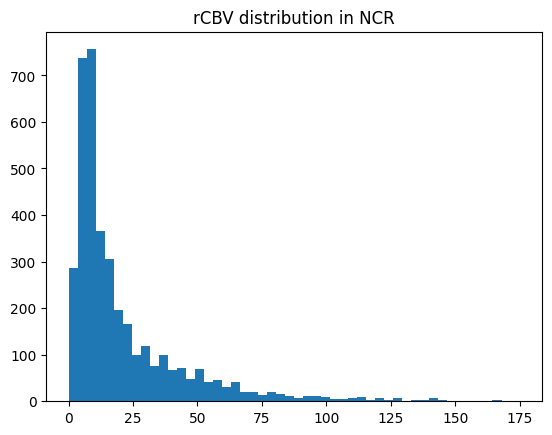

In [20]:
plt.hist(rcbv[seg==1], bins=50)
plt.title("rCBV distribution in NCR")
plt.show()

In [21]:
!pip install scipy

In [22]:
import numpy as np
import nibabel as nib
from scipy.stats import skew, kurtosis

def extract_rcbv_features(patient, base_path):
    
    # Load rCBV
    rcbv_path = f"{base_path}/images_DSC/{patient}_DSC_ap-rCBV.nii"
    rcbv = nib.load(rcbv_path).get_fdata()
    
    # Load segmentation
    seg_path = f"{base_path}/images_segm/{patient}_segm.nii"
    seg = nib.load(seg_path).get_fdata()
    
    # Extract NCR mask (label = 1)
    ncr_mask = (seg == 1)
    
    # Extract rCBV values inside NCR
    ncr_rcbv = rcbv[ncr_mask]
    
    # Remove zeros & NaNs
    ncr_rcbv = ncr_rcbv[ncr_rcbv > 0]
    ncr_rcbv = ncr_rcbv[~np.isnan(ncr_rcbv)]
    
    if len(ncr_rcbv) == 0:
        return None
    
    features = {
        "patient_id": patient,
        "mean_rCBV": np.mean(ncr_rcbv),
        "median_rCBV": np.median(ncr_rcbv),
        "std_rCBV": np.std(ncr_rcbv),
        "min_rCBV": np.min(ncr_rcbv),
        "max_rCBV": np.max(ncr_rcbv),
        "p90_rCBV": np.percentile(ncr_rcbv, 90),
        "skewness_rCBV": skew(ncr_rcbv),
        "kurtosis_rCBV": kurtosis(ncr_rcbv)
        
    }
    
    return features
    

In [23]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural"

# Get patient IDs automatically
structural_dir = "/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10/images_structural"
files = os.listdir(structural_dir)
patients = [f.replace("_T1GD.nii", "") for f in files]

# Correct base root
root_path = "/kaggle/input/datasets/neel17madhavpadhi/gbm-sample/GBM_sample_10"

vascular_features_list = []

for patient in patients:
    features = extract_rcbv_features(patient, root_path)
    if features:
        vascular_features_list.append(features)

vascular_df = pd.DataFrame(vascular_features_list)

vascular_df

,patient_id,mean_rCBV,median_rCBV,std_rCBV,min_rCBV,max_rCBV,p90_rCBV,skewness_rCBV,kurtosis_rCBV
0,UPENN-GBM-00404_11,20.853894,11.0,23.534080,1.0,175.0,51.0,2.411420,7.122169
1,UPENN-GBM-00418_11,44.134182,34.0,38.091947,1.0,252.0,95.0,1.434268,2.483805
2,UPENN-GBM-00428_11,34.221429,31.5,16.963856,5.0,83.0,60.0,0.621572,-0.122634
3,UPENN-GBM-00158_11,50.147264,38.0,40.364989,1.0,256.0,111.0,1.279874,1.300016
4,UPENN-GBM-00439_11,21.953280,17.0,16.496364,3.0,94.0,46.0,1.397920,1.821471
5,UPENN-GBM-00437_11,39.405506,33.0,30.265121,1.0,251.0,80.0,1.280898,2.478511
6,UPENN-GBM-00166_11,72.186459,68.0,25.417331,7.0,183.0,106.0,0.473683,0.622013


In [24]:
vascular_df.to_csv("vascular_features_step1.csv", index=False)

In [25]:
!pip install git+https://github.com/Radiomics/pyradiomics.git

  Cloning https://github.com/Radiomics/pyradiomics.git to /tmp/pip-req-build-sar95z02
  Running command git clone --filter=blob:none --quiet https://github.com/Radiomics/pyradiomics.git /tmp/pip-req-build-sar95z02
  Resolved https://github.com/Radiomics/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for pyradiomics: filename=pyradiomics-3.1.1.dev111+g8ed579383-cp312-cp312-linux_x86_64.whl size=121811 sha256=53c7378fda82b447cc61224032a53a519dbfb3557bf56402b3df6358c55bd8da
  Stored in directory: /tmp/pip-ephem-wheel-cache-ze59kdur/wheels/33/e9/c0/7de3e16cb600bae494d4a94dcd6c30a0443f06fb7359e87aa3
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=90574db58329225a01a08118e3b571ba3d1bd918b79710b2d311d1

In [26]:
from radiomics import featureextractor
import SimpleITK as sitk
import pandas as pd
import os

In [27]:
from radiomics import featureextractor
import SimpleITK as sitk

params = {
    'binWidth': 25,
    'resampledPixelSpacing': None,
    'interpolator': sitk.sitkBSpline,
    'enableCExtensions': True
}

extractor = featureextractor.RadiomicsFeatureExtractor(**params)

extractor.enableFeatureClassByName('shape')
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('gldm')
extractor.enableFeatureClassByName('ngtdm')

In [28]:
patient = "UPENN-GBM-00404_11"

image_path = f"{base}/images_structural/{patient}_T1GD.nii"
mask_path = f"{base}/images_segm/{patient}_segm.nii"

features_test = extractor.execute(image_path, mask_path, label=4)

print(len(features_test))

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


129


In [29]:
import pandas as pd

clean_test = {k: v for k, v in features_test.items() if 'diagnostics' not in k}

df_test = pd.DataFrame([clean_test])
df_test.shape

(1, 107)

In [30]:
def clean_features(feature_dict):
    return {k: v for k, v in feature_dict.items() if 'diagnostics' not in k}

patient = "UPENN-GBM-00404_11"

image_path = f"{base}/images_structural/{patient}_T1GD.nii"
mask_path = f"{base}/images_segm/{patient}_segm.nii"

features_et = clean_features(extractor.execute(image_path, mask_path, label=4))
features_ncr = clean_features(extractor.execute(image_path, mask_path, label=1))
features_ed = clean_features(extractor.execute(image_path, mask_path, label=2))

print("ET features:", len(features_et))
print("NCR features:", len(features_ncr))
print("ED features:", len(features_ed))

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


ET features: 107
NCR features: 107
ED features: 107


In [31]:
features_et = {f"ET_{k}": v for k, v in features_et.items()}
features_ncr = {f"NCR_{k}": v for k, v in features_ncr.items()}
features_ed = {f"ED_{k}": v for k, v in features_ed.items()}

combined = {}
combined.update(features_et)
combined.update(features_ncr)
combined.update(features_ed)

len(combined)

321

In [32]:
structural_dir = f"{base}/images_structural"
patients = [f.replace("_T1GD.nii", "") for f in os.listdir(structural_dir)]

radiomics_list = []

for patient in patients:
    
    image_path = f"{base}/images_structural/{patient}_T1GD.nii"
    mask_path = f"{base}/images_segm/{patient}_segm.nii"
    
    try:
        features_et = clean_features(extractor.execute(image_path, mask_path, label=4))
        features_ncr = clean_features(extractor.execute(image_path, mask_path, label=1))
        features_ed = clean_features(extractor.execute(image_path, mask_path, label=2))
        
        features_et = {f"ET_{k}": v for k, v in features_et.items()}
        features_ncr = {f"NCR_{k}": v for k, v in features_ncr.items()}
        features_ed = {f"ED_{k}": v for k, v in features_ed.items()}
        
        combined = {}
        combined["patient_id"] = patient
        combined.update(features_et)
        combined.update(features_ncr)
        combined.update(features_ed)
        
        radiomics_list.append(combined)
        
    except Exception as e:
        print(f"Error with {patient}: {e}")

radiomics_df = pd.DataFrame(radiomics_list)

radiomics_df.shape

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

(7, 322)

In [33]:
radiomics_df.head()

,patient_id,ET_original_shape_Elongation,ET_original_shape_Flatness,ET_original_shape_LeastAxisLength,ET_original_shape_MajorAxisLength,ET_original_shape_Maximum2DDiameterColumn,ET_original_shape_Maximum2DDiameterRow,ET_original_shape_Maximum2DDiameterSlice,ET_original_shape_Maximum3DDiameter,ET_original_shape_MeshVolume,...,ED_original_glszm_SmallAreaHighGrayLevelEmphasis,ED_original_glszm_SmallAreaLowGrayLevelEmphasis,ED_original_glszm_ZoneEntropy,ED_original_glszm_ZonePercentage,ED_original_glszm_ZoneVariance,ED_original_ngtdm_Busyness,ED_original_ngtdm_Coarseness,ED_original_ngtdm_Complexity,ED_original_ngtdm_Contrast,ED_original_ngtdm_Strength
0,UPENN-GBM-00404_11,0.776210,0.533046,27.492154,51.575528,52.3450093132096,71.61005515987263,60.67124524847005,72.84229540589725,31981.208333333332,...,149.32083257354034,0.003099758461775286,6.0383088387821795,0.0481994459833795,314904.3078222024,23.786013223866863,8.819739616095165e-05,219.07389405032194,0.010800237961095895,0.03153666192073723
1,UPENN-GBM-00418_11,0.833018,0.534911,23.610565,44.139199,49.36598018878993,49.24428900898052,46.32493928760188,50.79370039680118,16336.208333333334,...,122.78250819735372,0.008101838201206137,5.916822763473633,0.12291678201649964,9920.423508440874,3.676364208614856,0.0004990930046825701,643.3914330319013,0.013435206951599462,0.46450498544110974
2,UPENN-GBM-00428_11,0.806367,0.516522,15.267466,29.558224,32.38826948140329,33.28663395418648,34.785054261852174,34.79942528261063,6181.333333333333,...,53.92484366926556,0.01569928713154553,5.916830487544347,0.03911409395973155,149154.1536435234,17.838721306792063,0.00025760471871170173,168.55323472136703,0.010503445682979522,0.08609402785518666
3,UPENN-GBM-00158_11,0.755504,0.442212,21.981001,49.706923,48.104053883222775,45.044422518220834,53.9351462406472,55.65968020030299,6423.458333333333,...,144.73723818741504,0.00516761346812781,6.117227922683668,0.06977652127086699,88815.07361326,12.931297379792756,0.00013900508251549372,333.80071072758795,0.012859274820357888,0.06986078737668289
4,UPENN-GBM-00439_11,0.655388,0.573047,23.332043,40.715743,45.0111097397076,44.28317965096906,30.805843601498726,45.05552130427524,14482.75,...,66.55175337674171,0.008341028544663955,5.583802726182134,0.029114884182274346,174082.45294998813,13.550564394062013,0.0003538960648428072,73.95191939696122,0.011568228020406211,0.05842348647267801


In [34]:
radiomics_df.to_csv("radiomics_features_step2.csv", index=False)

In [35]:
vascular_df.head()

,patient_id,mean_rCBV,median_rCBV,std_rCBV,min_rCBV,max_rCBV,p90_rCBV,skewness_rCBV,kurtosis_rCBV
0,UPENN-GBM-00404_11,20.853894,11.0,23.534080,1.0,175.0,51.0,2.411420,7.122169
1,UPENN-GBM-00418_11,44.134182,34.0,38.091947,1.0,252.0,95.0,1.434268,2.483805
2,UPENN-GBM-00428_11,34.221429,31.5,16.963856,5.0,83.0,60.0,0.621572,-0.122634
3,UPENN-GBM-00158_11,50.147264,38.0,40.364989,1.0,256.0,111.0,1.279874,1.300016
4,UPENN-GBM-00439_11,21.953280,17.0,16.496364,3.0,94.0,46.0,1.397920,1.821471


In [36]:
vascular_df.describe()

,mean_rCBV,median_rCBV,std_rCBV,min_rCBV,max_rCBV,p90_rCBV,skewness_rCBV,kurtosis_rCBV
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,40.414573,33.214286,27.304812,2.714286,184.857143,78.428571,1.271376,2.243622
std,17.705113,18.225113,9.462495,2.429972,73.795728,26.588576,0.632583,2.352675
min,20.853894,11.000000,16.496364,1.000000,83.000000,46.000000,0.473683,-0.122634
25%,28.087354,24.250000,20.248968,1.000000,134.500000,55.500000,0.950723,0.961014
50%,39.405506,33.000000,25.417331,1.000000,183.000000,80.000000,1.280898,1.821471
75%,47.140723,36.000000,34.178534,4.000000,251.500000,100.500000,1.416094,2.481158
max,72.186459,68.000000,40.364989,7.000000,256.000000,111.000000,2.411420,7.122169


In [37]:
radiomics_df.columns[:30]

Index(['patient_id', 'ET_original_shape_Elongation',
       'ET_original_shape_Flatness', 'ET_original_shape_LeastAxisLength',
       'ET_original_shape_MajorAxisLength',
       'ET_original_shape_Maximum2DDiameterColumn',
       'ET_original_shape_Maximum2DDiameterRow',
       'ET_original_shape_Maximum2DDiameterSlice',
       'ET_original_shape_Maximum3DDiameter', 'ET_original_shape_MeshVolume',
       'ET_original_shape_MinorAxisLength', 'ET_original_shape_Sphericity',
       'ET_original_shape_SurfaceArea', 'ET_original_shape_SurfaceVolumeRatio',
       'ET_original_shape_VoxelVolume', 'ET_original_firstorder_10Percentile',
       'ET_original_firstorder_90Percentile', 'ET_original_firstorder_Energy',
       'ET_original_firstorder_Entropy',
       'ET_original_firstorder_InterquartileRange',
       'ET_original_firstorder_Kurtosis', 'ET_original_firstorder_Maximum',
       'ET_original_firstorder_MeanAbsoluteDeviation',
       'ET_original_firstorder_Mean', 'ET_original_firstorder

In [38]:
et_features = [c for c in radiomics_df.columns if c.startswith("ET_")]
ncr_features = [c for c in radiomics_df.columns if c.startswith("NCR_")]
ed_features = [c for c in radiomics_df.columns if c.startswith("ED_")]

print("ET:", len(et_features))
print("NCR:", len(ncr_features))
print("ED:", len(ed_features))

ET: 107
NCR: 107
ED: 107


In [39]:
radiomics_df.iloc[0]

patient_id                              UPENN-GBM-00404_11
ET_original_shape_Elongation                       0.77621
ET_original_shape_Flatness                        0.533046
ET_original_shape_LeastAxisLength                27.492154
ET_original_shape_MajorAxisLength                51.575528
                                             ...          
ED_original_ngtdm_Busyness              23.786013223866863
ED_original_ngtdm_Coarseness         8.819739616095165e-05
ED_original_ngtdm_Complexity            219.07389405032194
ED_original_ngtdm_Contrast            0.010800237961095895
ED_original_ngtdm_Strength             0.03153666192073723
Name: 0, Length: 322, dtype: object

In [40]:
radiomics_df.head()
vascular_df.head()

,patient_id,mean_rCBV,median_rCBV,std_rCBV,min_rCBV,max_rCBV,p90_rCBV,skewness_rCBV,kurtosis_rCBV
0,UPENN-GBM-00404_11,20.853894,11.0,23.534080,1.0,175.0,51.0,2.411420,7.122169
1,UPENN-GBM-00418_11,44.134182,34.0,38.091947,1.0,252.0,95.0,1.434268,2.483805
2,UPENN-GBM-00428_11,34.221429,31.5,16.963856,5.0,83.0,60.0,0.621572,-0.122634
3,UPENN-GBM-00158_11,50.147264,38.0,40.364989,1.0,256.0,111.0,1.279874,1.300016
4,UPENN-GBM-00439_11,21.953280,17.0,16.496364,3.0,94.0,46.0,1.397920,1.821471


In [41]:
vascular_df.to_csv("/kaggle/working/vascular_features.csv", index=False)

In [42]:
radiomics_df.to_csv("/kaggle/working/radiomics_features.csv", index=False)

In [43]:
final_features = radiomics_df.merge(vascular_df, on="patient_id")

final_features.to_csv("/kaggle/working/imaging_features_dataset.csv", index=False)

In [44]:
import pandas as pd

clinical = pd.read_csv("/kaggle/input/datasets/neel17madhavpadhi/gbm-csv/UPENN-GBM_clinical_info_v2.1 (1).csv")
availability = pd.read_csv("/kaggle/input/datasets/neel17madhavpadhi/gbm-csv/UPENN-GBM_data_availability (1).csv")

In [47]:
clinical.head()
clinical.columns

Index(['ID', 'Gender', 'Age_at_scan_years',
       'Survival_from_surgery_days_UPDATED', 'Survival_Status',
       'Survival_Censor', 'IDH1', 'MGMT', 'KPS', 'GTR_over90percent',
       'Time_since_baseline_preop', 'PsP_TP_score'],
      dtype='object')

In [49]:
imaging_features = radiomics_df.merge(
    vascular_df,
    on="patient_id"
)

In [50]:
imaging_features.shape
imaging_features.head()

,patient_id,ET_original_shape_Elongation,ET_original_shape_Flatness,ET_original_shape_LeastAxisLength,ET_original_shape_MajorAxisLength,ET_original_shape_Maximum2DDiameterColumn,ET_original_shape_Maximum2DDiameterRow,ET_original_shape_Maximum2DDiameterSlice,ET_original_shape_Maximum3DDiameter,ET_original_shape_MeshVolume,...,ED_original_ngtdm_Contrast,ED_original_ngtdm_Strength,mean_rCBV,median_rCBV,std_rCBV,min_rCBV,max_rCBV,p90_rCBV,skewness_rCBV,kurtosis_rCBV
0,UPENN-GBM-00404_11,0.776210,0.533046,27.492154,51.575528,52.3450093132096,71.61005515987263,60.67124524847005,72.84229540589725,31981.208333333332,...,0.010800237961095895,0.03153666192073723,20.853894,11.0,23.534080,1.0,175.0,51.0,2.411420,7.122169
1,UPENN-GBM-00418_11,0.833018,0.534911,23.610565,44.139199,49.36598018878993,49.24428900898052,46.32493928760188,50.79370039680118,16336.208333333334,...,0.013435206951599462,0.46450498544110974,44.134182,34.0,38.091947,1.0,252.0,95.0,1.434268,2.483805
2,UPENN-GBM-00428_11,0.806367,0.516522,15.267466,29.558224,32.38826948140329,33.28663395418648,34.785054261852174,34.79942528261063,6181.333333333333,...,0.010503445682979522,0.08609402785518666,34.221429,31.5,16.963856,5.0,83.0,60.0,0.621572,-0.122634
3,UPENN-GBM-00158_11,0.755504,0.442212,21.981001,49.706923,48.104053883222775,45.044422518220834,53.9351462406472,55.65968020030299,6423.458333333333,...,0.012859274820357888,0.06986078737668289,50.147264,38.0,40.364989,1.0,256.0,111.0,1.279874,1.300016
4,UPENN-GBM-00439_11,0.655388,0.573047,23.332043,40.715743,45.0111097397076,44.28317965096906,30.805843601498726,45.05552130427524,14482.75,...,0.011568228020406211,0.05842348647267801,21.953280,17.0,16.496364,3.0,94.0,46.0,1.397920,1.821471


In [51]:
final_dataset = imaging_features.merge(
    clinical,
    left_on="patient_id",
    right_on="ID",
    how="inner"
)

In [52]:
final_dataset.shape
final_dataset.head()

,patient_id,ET_original_shape_Elongation,ET_original_shape_Flatness,ET_original_shape_LeastAxisLength,ET_original_shape_MajorAxisLength,ET_original_shape_Maximum2DDiameterColumn,ET_original_shape_Maximum2DDiameterRow,ET_original_shape_Maximum2DDiameterSlice,ET_original_shape_Maximum3DDiameter,ET_original_shape_MeshVolume,...,Age_at_scan_years,Survival_from_surgery_days_UPDATED,Survival_Status,Survival_Censor,IDH1,MGMT,KPS,GTR_over90percent,Time_since_baseline_preop,PsP_TP_score
0,UPENN-GBM-00404_11,0.776210,0.533046,27.492154,51.575528,52.3450093132096,71.61005515987263,60.67124524847005,72.84229540589725,31981.208333333332,...,66.36,688,Deceased,Not Available,Wildtype,Methylated,40,Y,0,NaN
1,UPENN-GBM-00418_11,0.833018,0.534911,23.610565,44.139199,49.36598018878993,49.24428900898052,46.32493928760188,50.79370039680118,16336.208333333334,...,49.61,1410,Deceased,Not Available,Wildtype,Methylated,Not Available,Y,0,NaN
2,UPENN-GBM-00428_11,0.806367,0.516522,15.267466,29.558224,32.38826948140329,33.28663395418648,34.785054261852174,34.79942528261063,6181.333333333333,...,64.76,374,Deceased,Not Available,Wildtype,Unmethylated,Not Available,N,0,NaN
3,UPENN-GBM-00158_11,0.755504,0.442212,21.981001,49.706923,48.104053883222775,45.044422518220834,53.9351462406472,55.65968020030299,6423.458333333333,...,69.68,152,Deceased,Not Available,NOS/NEC,Not Available,Not Available,Y,0,NaN
4,UPENN-GBM-00439_11,0.655388,0.573047,23.332043,40.715743,45.0111097397076,44.28317965096906,30.805843601498726,45.05552130427524,14482.75,...,47.21,264,Deceased,Not Available,Wildtype,Methylated,Not Available,N,0,NaN


In [53]:
print("Imaging patients:")
print(imaging_features["patient_id"].tolist())

print("\nClinical patients:")
print(clinical["ID"].tolist())

Imaging patients:
['UPENN-GBM-00404_11', 'UPENN-GBM-00418_11', 'UPENN-GBM-00428_11', 'UPENN-GBM-00158_11', 'UPENN-GBM-00439_11', 'UPENN-GBM-00437_11', 'UPENN-GBM-00166_11']

Clinical patients:
['UPENN-GBM-00001_11', 'UPENN-GBM-00002_11', 'UPENN-GBM-00003_11', 'UPENN-GBM-00004_11', 'UPENN-GBM-00005_11', 'UPENN-GBM-00006_11', 'UPENN-GBM-00007_11', 'UPENN-GBM-00008_11', 'UPENN-GBM-00009_11', 'UPENN-GBM-00010_11', 'UPENN-GBM-00011_11', 'UPENN-GBM-00012_11', 'UPENN-GBM-00013_11', 'UPENN-GBM-00014_11', 'UPENN-GBM-00015_11', 'UPENN-GBM-00016_11', 'UPENN-GBM-00017_11', 'UPENN-GBM-00018_11', 'UPENN-GBM-00019_11', 'UPENN-GBM-00020_11', 'UPENN-GBM-00021_11', 'UPENN-GBM-00022_11', 'UPENN-GBM-00023_11', 'UPENN-GBM-00024_11', 'UPENN-GBM-00025_11', 'UPENN-GBM-00026_11', 'UPENN-GBM-00027_11', 'UPENN-GBM-00028_11', 'UPENN-GBM-00029_11', 'UPENN-GBM-00030_11', 'UPENN-GBM-00031_11', 'UPENN-GBM-00032_11', 'UPENN-GBM-00033_11', 'UPENN-GBM-00034_11', 'UPENN-GBM-00035_11', 'UPENN-GBM-00036_11', 'UPENN-GBM-000

In [55]:
final_dataset[[
    "patient_id",
    "Survival_from_surgery_days_UPDATED",
    "Survival_Status"
]]

,patient_id,Survival_from_surgery_days_UPDATED,Survival_Status
0,UPENN-GBM-00404_11,688,Deceased
1,UPENN-GBM-00418_11,1410,Deceased
2,UPENN-GBM-00428_11,374,Deceased
3,UPENN-GBM-00158_11,152,Deceased
4,UPENN-GBM-00439_11,264,Deceased
5,UPENN-GBM-00437_11,82,Deceased
6,UPENN-GBM-00166_11,388,Deceased


In [56]:
final_dataset.isna().sum()

patient_id                           0
ET_original_shape_Elongation         0
ET_original_shape_Flatness           0
ET_original_shape_LeastAxisLength    0
ET_original_shape_MajorAxisLength    0
                                    ..
MGMT                                 0
KPS                                  0
GTR_over90percent                    0
Time_since_baseline_preop            0
PsP_TP_score                         7
Length: 342, dtype: int64

In [57]:
final_dataset = final_dataset.dropna(axis=1, how="all")

In [58]:
final_dataset.isna().sum().sort_values(ascending=False).head(10)

Time_since_baseline_preop                    0
patient_id                                   0
ET_original_shape_Elongation                 0
ET_original_shape_Flatness                   0
ET_original_shape_LeastAxisLength            0
ET_original_shape_MajorAxisLength            0
ET_original_shape_Maximum2DDiameterColumn    0
ET_original_shape_Maximum2DDiameterRow       0
ET_original_shape_Maximum2DDiameterSlice     0
ET_original_shape_Maximum3DDiameter          0
dtype: int64

In [59]:
print(final_dataset.shape)

(7, 341)


In [60]:
final_dataset["event"] = final_dataset["Survival_Status"].apply(
    lambda x: 1 if x == "Deceased" else 0
)

In [61]:
time = final_dataset["Survival_from_surgery_days_UPDATED"]
event = final_dataset["event"]

In [62]:
X = final_dataset.drop(columns=[
    "patient_id",
    "ID",
    "Survival_from_surgery_days_UPDATED",
    "Survival_Status",
    "Survival_Censor",
    "event"
])

In [64]:
for col in X.columns:
    if isinstance(X[col].iloc[0], (list, np.ndarray)):
        print(col)

ET_original_shape_Maximum2DDiameterColumn
ET_original_shape_Maximum2DDiameterRow
ET_original_shape_Maximum2DDiameterSlice
ET_original_shape_Maximum3DDiameter
ET_original_shape_MeshVolume
ET_original_shape_Sphericity
ET_original_shape_SurfaceArea
ET_original_shape_SurfaceVolumeRatio
ET_original_firstorder_10Percentile
ET_original_firstorder_90Percentile
ET_original_firstorder_Energy
ET_original_firstorder_Entropy
ET_original_firstorder_InterquartileRange
ET_original_firstorder_Kurtosis
ET_original_firstorder_Maximum
ET_original_firstorder_MeanAbsoluteDeviation
ET_original_firstorder_Mean
ET_original_firstorder_Median
ET_original_firstorder_Minimum
ET_original_firstorder_Range
ET_original_firstorder_RobustMeanAbsoluteDeviation
ET_original_firstorder_RootMeanSquared
ET_original_firstorder_Skewness
ET_original_firstorder_TotalEnergy
ET_original_firstorder_Uniformity
ET_original_firstorder_Variance
ET_original_glcm_Autocorrelation
ET_original_glcm_ClusterProminence
ET_original_glcm_ClusterS

In [65]:
cols_to_drop = []

for col in X.columns:
    if isinstance(X[col].iloc[0], (list, np.ndarray)):
        cols_to_drop.append(col)

print("Dropping:", cols_to_drop)

X = X.drop(columns=cols_to_drop)

Dropping: ['ET_original_shape_Maximum2DDiameterColumn', 'ET_original_shape_Maximum2DDiameterRow', 'ET_original_shape_Maximum2DDiameterSlice', 'ET_original_shape_Maximum3DDiameter', 'ET_original_shape_MeshVolume', 'ET_original_shape_Sphericity', 'ET_original_shape_SurfaceArea', 'ET_original_shape_SurfaceVolumeRatio', 'ET_original_firstorder_10Percentile', 'ET_original_firstorder_90Percentile', 'ET_original_firstorder_Energy', 'ET_original_firstorder_Entropy', 'ET_original_firstorder_InterquartileRange', 'ET_original_firstorder_Kurtosis', 'ET_original_firstorder_Maximum', 'ET_original_firstorder_MeanAbsoluteDeviation', 'ET_original_firstorder_Mean', 'ET_original_firstorder_Median', 'ET_original_firstorder_Minimum', 'ET_original_firstorder_Range', 'ET_original_firstorder_RobustMeanAbsoluteDeviation', 'ET_original_firstorder_RootMeanSquared', 'ET_original_firstorder_Skewness', 'ET_original_firstorder_TotalEnergy', 'ET_original_firstorder_Uniformity', 'ET_original_firstorder_Variance', 'ET_

In [66]:
X.head()

,ET_original_shape_Elongation,ET_original_shape_Flatness,ET_original_shape_LeastAxisLength,ET_original_shape_MajorAxisLength,ET_original_shape_MinorAxisLength,ET_original_shape_VoxelVolume,NCR_original_shape_Elongation,NCR_original_shape_Flatness,NCR_original_shape_LeastAxisLength,NCR_original_shape_MajorAxisLength,...,p90_rCBV,skewness_rCBV,kurtosis_rCBV,Gender,Age_at_scan_years,IDH1,MGMT,KPS,GTR_over90percent,Time_since_baseline_preop
0,0.776210,0.533046,27.492154,51.575528,40.033457,31930.0,0.771394,0.374409,18.672797,49.872662,...,51.0,2.411420,7.122169,M,66.36,Wildtype,Methylated,40,Y,0
1,0.833018,0.534911,23.610565,44.139199,36.768748,16375.0,0.648807,0.341589,12.471199,36.509412,...,95.0,1.434268,2.483805,F,49.61,Wildtype,Methylated,Not Available,Y,0
2,0.806367,0.516522,15.267466,29.558224,23.834766,6206.0,0.480268,0.292872,6.512449,22.236540,...,60.0,0.621572,-0.122634,M,64.76,Wildtype,Unmethylated,Not Available,N,0
3,0.755504,0.442212,21.981001,49.706923,37.553791,6603.0,0.905039,0.702895,20.545058,29.229179,...,111.0,1.279874,1.300016,M,69.68,NOS/NEC,Not Available,Not Available,Y,0
4,0.655388,0.573047,23.332043,40.715743,26.684595,14480.0,0.427952,0.323401,9.945128,30.751737,...,46.0,1.397920,1.821471,F,47.21,Wildtype,Methylated,Not Available,N,0


In [67]:
X = pd.get_dummies(X, drop_first=True)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
print(X_scaled.shape)
print(len(time), len(event))

(7, 34)
7 7


In [70]:
print(X_scaled.shape)

(7, 34)


In [71]:
!pip install pycox torchtuples

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 13.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.2 MB/s eta 0:00:00
  Created wheel for feather-format: filename=feather_format-0.4.1-py3-none-any.whl size=2434 sha256=3587aabbb7da280e6756c4e267d6087cca59e519aa487a6e163d6cdde07126bb
  Stored in directory: /root/.cache/pip/wheels/dd/02/6b/2f0f7e1c0454094c880e63076da142e67f1ba72f82baa6195f
Successfully built feather-format


In [72]:
import torch
import torchtuples as tt
from pycox.models import CoxPH

In [73]:
import numpy as np

X_train = X_scaled.astype("float32")
y_time = time.values.astype("float32")
y_event = event.values.astype("int64")

y = (y_time, y_event)

In [74]:
in_features = X_train.shape[1]

net = tt.practical.MLPVanilla(
    in_features,
    [16, 8],     # small network
    1,
    batch_norm=True,
    dropout=0.1
)

In [75]:
model = CoxPH(net, tt.optim.Adam)
model.optimizer.set_lr(0.01)

In [76]:
batch_size = 4
epochs = 100

model.fit(
    X_train,
    y,
    batch_size,
    epochs,
    verbose=True
)

0:	[0s / 0s],		train_loss: 1.2129
1:	[0s / 0s],		train_loss: 0.6267
2:	[0s / 0s],		train_loss: 0.5283
3:	[0s / 0s],		train_loss: 0.6507
4:	[0s / 0s],		train_loss: 0.4116
5:	[0s / 0s],		train_loss: 0.5998
6:	[0s / 0s],		train_loss: 0.5701
7:	[0s / 0s],		train_loss: 0.4722
8:	[0s / 0s],		train_loss: 0.3476
9:	[0s / 0s],		train_loss: 0.3961
10:	[0s / 1s],		train_loss: 0.8231
11:	[0s / 1s],		train_loss: 0.4329
12:	[0s / 1s],		train_loss: 0.4541
13:	[0s / 1s],		train_loss: 0.2789
14:	[0s / 1s],		train_loss: 0.2350
15:	[0s / 1s],		train_loss: 0.4062
16:	[0s / 1s],		train_loss: 0.2585
17:	[0s / 1s],		train_loss: 0.2844
18:	[0s / 1s],		train_loss: 0.2706
19:	[0s / 1s],		train_loss: 0.1930
20:	[0s / 1s],		train_loss: 0.3048
21:	[0s / 1s],		train_loss: 0.4082
22:	[0s / 1s],		train_loss: 0.2636
23:	[0s / 1s],		train_loss: 0.2780
24:	[0s / 1s],		train_loss: 0.2452
25:	[0s / 1s],		train_loss: 0.1281
26:	[0s / 1s],		train_loss: 0.1681
27:	[0s / 1s],		train_loss: 0.1375
28:	[0s / 1s],		train_loss: 0.

In [77]:
risk_scores = model.predict(X_train)
print(risk_scores)

[[-1.1321616]
 [-3.5812025]
 [ 1.3127937]
 [ 2.9356568]
 [ 2.6250963]
 [ 5.7586913]
 [-1.7071252]]


In [78]:
import pandas as pd

results = pd.DataFrame({
    "patient": final_dataset["patient_id"],
    "risk_score": risk_scores.flatten(),
    "survival_days": time
})

results = results.sort_values("risk_score", ascending=False)
results

,patient,risk_score,survival_days
5,UPENN-GBM-00437_11,5.758691,82
3,UPENN-GBM-00158_11,2.935657,152
4,UPENN-GBM-00439_11,2.625096,264
2,UPENN-GBM-00428_11,1.312794,374
0,UPENN-GBM-00404_11,-1.132162,688
6,UPENN-GBM-00166_11,-1.707125,388
1,UPENN-GBM-00418_11,-3.581203,1410


In [79]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7380d5684ea8bdb1c243bc0224ec1a1684bbf495412745996f5c4b4a0d127f4d
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [80]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [81]:
median_risk = results["risk_score"].median()

results["risk_group"] = results["risk_score"].apply(
    lambda x: "High Risk" if x > median_risk else "Low Risk"
)

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)
/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


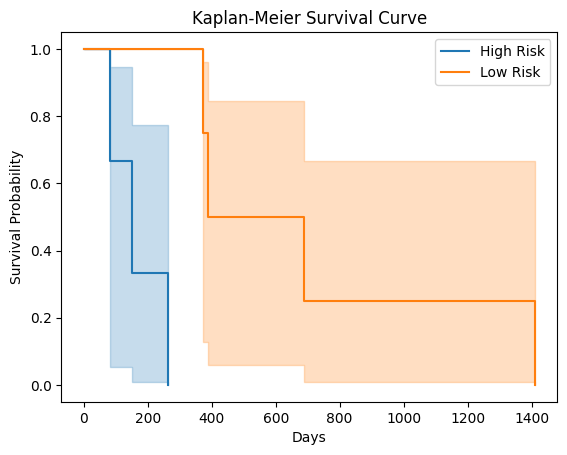

In [82]:
kmf = KaplanMeierFitter()

for group in ["High Risk", "Low Risk"]:
    group_data = results[results["risk_group"] == group]
    
    kmf.fit(
        durations=group_data["survival_days"],
        event_observed=[1]*len(group_data),
        label=group
    )
    
    kmf.plot()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.show()

In [84]:
results.to_csv("risk_predictions.csv", index=False)

In [85]:
final_dataset.to_csv("final_dataset.csv", index=False)

In [86]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [87]:
model.save_model_weights("deepsurv_model.pt")

In [88]:
import zipfile
import os

zip_path = "/kaggle/working/gbm_project_complete.zip"

folder_path = "/kaggle/working"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith((".csv", ".pt", ".pkl")):  # only important files
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.basename(file_path))

print("ZIP created:", zip_path)

ZIP created: /kaggle/working/gbm_project_complete.zip
